# Advanced Analytics
This notebook covers Cohort Analysis, Recommender Logic, Monte Carlo Simulation (B3), and Markowitz Efficient Frontier (B4).

In [1]:
import pandas as pd
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt
import seaborn as sns

nav_history = pd.read_csv('../data/processed/nav_history.csv')
nav_history['date'] = pd.to_datetime(nav_history['date'])

txn = pd.read_csv('../data/processed/investor_transactions.csv')
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

fund_master = pd.read_csv('../data/processed/fund_master.csv')


## 1. Cohort Analysis (Investor Retention)

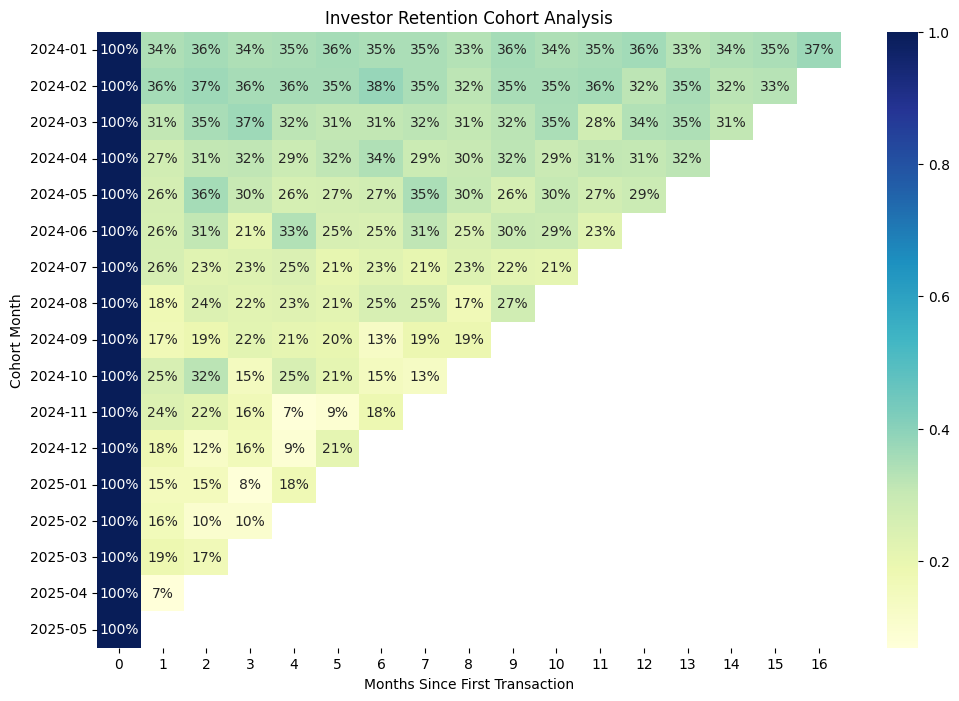

In [2]:
# Get first transaction month for each investor
txn['txn_month'] = txn['transaction_date'].dt.to_period('M')
first_txn = txn.groupby('investor_id')['txn_month'].min().reset_index()
first_txn.rename(columns={'txn_month': 'cohort_month'}, inplace=True)

cohort_df = pd.merge(txn, first_txn, on='investor_id')
cohort_df['cohort_index'] = (cohort_df['txn_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12 + (cohort_df['txn_month'].dt.month - cohort_df['cohort_month'].dt.month)

cohort_data = cohort_df.groupby(['cohort_month', 'cohort_index'])['investor_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='investor_id')
cohort_sizes = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Investor Retention Cohort Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Transaction')
plt.show()


## 2. Recommender Logic

In [3]:
# Basic content-based recommendation for a hypothetical investor.
# We recommend funds based on the category of funds they have heavily invested in.
def recommend_funds(investor_id, top_n=3):
    investor_txn = txn[txn['investor_id'] == investor_id]
    if investor_txn.empty:
        return []
    
    # Find most invested category
    invested_funds = investor_txn.groupby('amfi_code')['amount_inr'].sum().reset_index()
    invested_funds = pd.merge(invested_funds, fund_master[['amfi_code', 'category']], on='amfi_code')
    favorite_category = invested_funds.groupby('category')['amount_inr'].sum().idxmax()
    
    # Recommend top funds in that category by AUM that investor hasn't bought
    bought_amfi = investor_txn['amfi_code'].unique()
    recommendations = fund_master[(fund_master['category'] == favorite_category) & (~fund_master['amfi_code'].isin(bought_amfi))]
    # Proxying 'best' by lowest expense ratio for demonstration if AUM isn't fully robust here
    recommendations = recommendations.sort_values('expense_ratio_pct', ascending=True).head(top_n)
    
    return recommendations[['amfi_code', 'scheme_name', 'category', 'expense_ratio_pct']]

print("Recommendations for INV003054:")
display(recommend_funds('INV003054'))


Recommendations for INV003054:


,amfi_code,scheme_name,category,expense_ratio_pct
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,0.66
25,119093,Axis Bluechip Fund - Direct - Growth,Equity,0.75
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,0.78


## 3. Monte Carlo Simulation (B3)
Projecting NAV growth over 5 years (1260 days) using Geometric Brownian Motion.

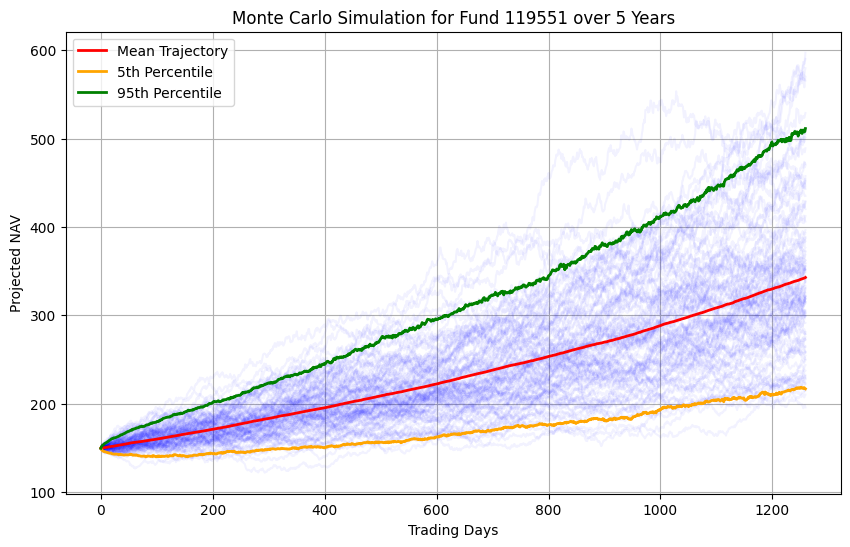

In [4]:
TRADING_DAYS = 252
SIM_DAYS = 5 * TRADING_DAYS
NUM_SIMULATIONS = 1000

# Select a popular fund: SBI Bluechip (119551)
amfi_code = 119551
fund_data = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date')
fund_data['return'] = fund_data['nav'].pct_change()
mu = fund_data['return'].mean()
sigma = fund_data['return'].std()
last_nav = fund_data['nav'].iloc[-1]

simulations = np.zeros((SIM_DAYS, NUM_SIMULATIONS))
simulations[0, :] = last_nav

for t in range(1, SIM_DAYS):
    random_shocks = np.random.normal(loc=mu, scale=sigma, size=NUM_SIMULATIONS)
    simulations[t, :] = simulations[t-1, :] * (1 + random_shocks)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(simulations[:, :100], color='blue', alpha=0.05) # Plot first 100 paths
plt.plot(np.mean(simulations, axis=1), color='red', linewidth=2, label='Mean Trajectory')
plt.plot(np.percentile(simulations, 5, axis=1), color='orange', linewidth=2, label='5th Percentile')
plt.plot(np.percentile(simulations, 95, axis=1), color='green', linewidth=2, label='95th Percentile')
plt.title(f'Monte Carlo Simulation for Fund {amfi_code} over 5 Years')
plt.xlabel('Trading Days')
plt.ylabel('Projected NAV')
plt.legend()
plt.grid(True)
plt.show()


## 4. Markowitz Efficient Frontier (B4)

Optimal Weights for Maximum Sharpe Ratio:
SBI Bluechip Fund - Regular Plan - Growth: 31.03%
ICICI Pru Bluechip Fund - Regular - Growth: 0.00%
Nippon India Large Cap Fund - Regular - Growth: 36.24%
Axis Bluechip Fund - Regular - Growth: 20.47%
Kotak Bluechip Fund - Regular - Growth: 12.27%


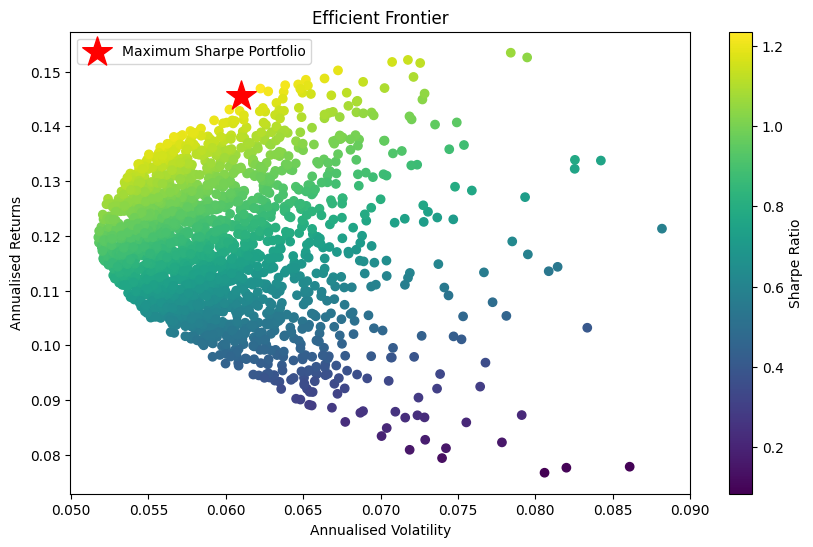

In [5]:
# We will select 5 funds for optimization
selected_funds = [119551, 120503, 118632, 119092, 120841]
pivot_nav = nav_history[nav_history['amfi_code'].isin(selected_funds)].pivot(index='date', columns='amfi_code', values='nav')
daily_returns = pivot_nav.pct_change().dropna()

mean_returns = daily_returns.mean() * TRADING_DAYS
cov_matrix = daily_returns.cov() * TRADING_DAYS
num_assets = len(selected_funds)
risk_free_rate = 0.07

def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    p_ret, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.0, 1.0) for asset in range(num_assets))
init_guess = num_assets * [1. / num_assets,]

optimal_sharpe = sco.minimize(negative_sharpe, init_guess, args=(mean_returns, cov_matrix, risk_free_rate),
                              method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = optimal_sharpe.x
print("Optimal Weights for Maximum Sharpe Ratio:")
for fund, weight in zip(selected_funds, optimal_weights):
    name = fund_master[fund_master['amfi_code'] == fund]['scheme_name'].values[0]
    print(f"{name}: {weight:.2%}")

# Efficient Frontier Plotting
results = np.zeros((3, 2000))
for i in range(2000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    p_ret, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    results[0,i] = p_std
    results[1,i] = p_ret
    results[2,i] = (p_ret - risk_free_rate) / p_std

plt.figure(figsize=(10, 6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(portfolio_performance(optimal_weights, mean_returns, cov_matrix)[1], 
            portfolio_performance(optimal_weights, mean_returns, cov_matrix)[0], 
            marker='*', color='r', s=500, label='Maximum Sharpe Portfolio')
plt.title('Efficient Frontier')
plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Returns')
plt.legend()
plt.show()
